In [14]:
import ase.io
import matplotlib.pyplot as plt
from ase.io import read
from fairchem.core.datasets.ase_datasets import AseDBDataset
import os
import glob
from ase.io import Trajectory
import matplotlib.pyplot as plt


In [25]:
# Load AseDBDataset
a2g_args = {  
    "r_energy": True,
    "r_forces": True,
    "r_stress": True,
    "r_data_keys": ['spin', 'charge']
}
path = '/global/cfs/cdirs/m4558/aug_29_first_100ps/combined/train'
path = '/global/cfs/cdirs/m4558/distillation_project/all_lmdbs/combined/train'

dataset = AseDBDataset({
                        "src": path,
                        "a2g_args": a2g_args,
                        })

In [17]:

root = '/global/cfs/cdirs/m4558/first_100ps_traj_to_send/'
root = '/global/cfs/cdirs/m4558/distillation_project/all_trajs_min50ps'
# root = '/global/cfs/cdirs/m4558/distillation_project/all_xyzs/per_systems/naotf_pc/train'
root = '/global/cfs/cdirs/m4558/distillation_project/all_xyzs/per_systems/cspf6/train'
root = '/global/cfs/cdirs/m4558/distillation_project/all_xyzs/combined/train'
for fname in os.listdir(root):
    if fname.endswith(".traj") or fname.endswith(".xyz"):
        path = os.path.join(root, fname)
        try:
            # Lazily read just the first frame
            atoms = read(path, index=0)
            print(atoms.calc)
            # energy = atoms.get_potential_energy()
            # print(f"{fname}: GOOD (energy = {energy})")
            print(atoms.info)
        except Exception as e:
            print(f"{fname}: potential energies not found ({e})")

SinglePointCalculator(energy=-1494965.2717799728, forces=..., stress=...)
{'Origin': array([-14.27895, -14.27895, -14.27895]), 'charge': np.int64(0), 'spin': np.int64(1), 'id': np.int64(0), 'uid': 'f00000000', 'system': 'cspf6', 'source_file': 'md_omol_cspf6_pfactor_0.1_1fs_mask_t.traj', 'source_index': np.int64(0)}


In [ ]:
import glob
from ase.io.trajectory import Trajectory

folder = '/global/cfs/cdirs/m4558/distillation_project/all_trajs_min50ps/'

for fname in sorted(glob.glob(folder + "*.traj")):
    try:
        # ASE loads lazily, so this won’t pull in all frames
        traj = Trajectory(fname)
        print(f"{os.path.basename(fname)}: {len(traj)} frames")
    except Exception as e:
        print(f"Could not read {fname}: {e}")


md_omol_napf6_diglyme_pfactor_0.1_1fs.traj: 10966 frames
md_omol_napf6_dme_re1.traj: 10001 frames


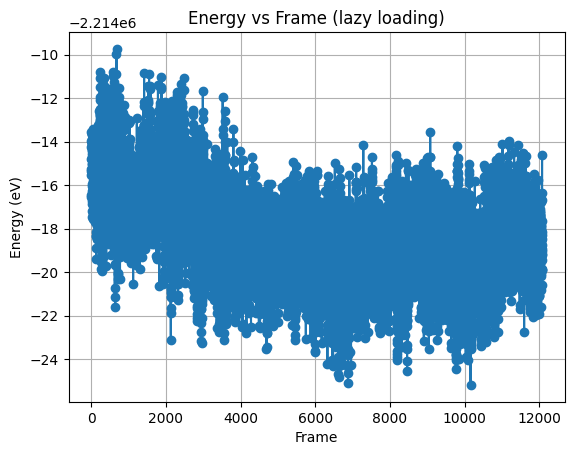

In [7]:
# Load ASE trajectory
# Load the trajectory
from ase.io import iread
import matplotlib.pyplot as plt
folder = '/global/cfs/cdirs/m4558/first_100ps_traj_to_send/'
traj_name = 'md_omol_naotf_dme_s1p1_omol.traj'
traj_name = 'md_omol_napf6_propylene_carbonate_pfactor_0.1_1fs_mask_t_re3_s1p1.traj'
path = os.path.join(folder, traj_name)

energies = []
for atoms in iread(path, index=":"):
    energies.append(atoms.get_potential_energy())

plt.plot(range(len(energies)), energies, marker="o", linestyle="-")
plt.xlabel("Frame")
plt.ylabel("Energy (eV)")
plt.title("Energy vs Frame (lazy loading)")
plt.grid(True)
plt.show()
